# Machine Learning for Multi-Omics Biology

This notebook demonstrates key ML concepts for biological data analysis using the ASD multi-omics dataset.

**Sections:**
1. Fundamental ML Concepts
2. Model Performance Metrics
3. LazyPredict Framework
4. Feature Selection Methods
5. Feature Importance for Biomarker Discovery

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold, RFE, SelectFromModel, mutual_info_classif
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score, 
                             roc_curve, precision_recall_curve, f1_score, 
                             precision_score, recall_score, average_precision_score)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

# Set random seed for reproducibility
np.random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the ASD multi-omics dataset
DATA_DIR = "../data/ASD_dataset/"

print("Loading ASD multi-omics dataset...\n")

# Load covariates (includes target variable 'ASD')
covariates = pd.read_csv(f"{DATA_DIR}ASD_covariates.csv")
print(f"✓ Covariates: {covariates.shape[0]} samples, {covariates.shape[1]} variables")

# Load genotype data (SNPs)
genotypes = pd.read_csv(f"{DATA_DIR}ASD_genotypes.csv")
print(f"✓ Genotypes: {genotypes.shape[0]} samples, {genotypes.shape[1]-1} SNPs")

# Load gene expression data (using expanded 100-gene dataset)
expression = pd.read_csv(f"{DATA_DIR}ASD_expression.csv")
print(f"✓ Expression: {expression.shape[0]} samples, {expression.shape[1]-1} genes")

# Set sample ID as index for easy merging
covariates_idx = covariates.set_index('sample')
genotypes_idx = genotypes.set_index('sample')
expression_idx = expression.set_index('sample')

# Create integrated feature matrix (multi-omics integration)
X_integrated = pd.DataFrame(index=expression_idx.index)

# Add gene expression features (NO prefix - use gene names directly)
for gene in expression_idx.columns:
    X_integrated[gene] = expression_idx[gene]

# Add top 10 SNP features (prefix with geno_)
for snp in genotypes_idx.columns[:10]:
    X_integrated[f'geno_{snp}'] = genotypes_idx[snp]

# Add clinical covariates
X_integrated['Age'] = covariates_idx['Age']
X_integrated['Sex'] = covariates_idx['Sex']

# Target variable: ASD status (1=case, 0=control)
y = covariates_idx['ASD'].values

print(f"\n✓ Integrated feature matrix: {X_integrated.shape}")
print(f"✓ Target distribution: {y.sum()} ASD cases, {len(y)-y.sum()} controls")
print(f"  Class ratio: {y.mean():.1%} cases")

Loading ASD multi-omics dataset...

✓ Covariates: 300 samples, 29 variables
✓ Genotypes: 300 samples, 50 SNPs
✓ Expression: 300 samples, 100 genes

✓ Integrated feature matrix: (300, 112)
✓ Target distribution: 200 ASD cases, 100 controls
  Class ratio: 66.7% cases


# Section 1: Fundamental ML Concepts

Demonstrates:
- Train/Test split with stratification
- Cross-validation
- Standardization vs Normalization
- Overfitting detection
- Regularization

In [3]:
# 1.1 Train-Test Split with Stratification
# Split data 70-30, preserving class proportions
print("=" * 80)
print("TRAIN-TEST SPLIT WITH STRATIFICATION")
print("=" * 80)

X_train, X_test, y_train, y_test = train_test_split(
    X_integrated, y,
    test_size=0.3,      # 30% for testing
    stratify=y,         # Preserve class proportions
    random_state=42
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"  ASD cases: {y_train.sum()} ({y_train.mean():.1%})")
print(f"  Controls: {len(y_train)-y_train.sum()} ({(1-y_train.mean()):.1%})")

print(f"\nTest set: {X_test.shape[0]} samples")
print(f"  ASD cases: {y_test.sum()} ({y_test.mean():.1%})")
print(f"  Controls: {len(y_test)-y_test.sum()} ({(1-y_test.mean()):.1%})")

print("\n✓ Class proportions preserved in both sets!")

TRAIN-TEST SPLIT WITH STRATIFICATION

Training set: 210 samples
  ASD cases: 140 (66.7%)
  Controls: 70 (33.3%)

Test set: 90 samples
  ASD cases: 60 (66.7%)
  Controls: 30 (33.3%)

✓ Class proportions preserved in both sets!


In [4]:
# 1.2 Standardization vs Normalization Example
# Using a gene with wide range to demonstrate difference
print("=" * 80)
print("STANDARDIZATION VS NORMALIZATION")
print("=" * 80)

# Select a gene for demonstration
example_gene = X_train.iloc[:, 0]  # First gene
print(f"\nExample gene: {X_train.columns[0]}")
print(f"Original range: [{example_gene.min():.2f}, {example_gene.max():.2f}]")
print(f"Mean: {example_gene.mean():.2f}, Std: {example_gene.std():.2f}")

# Standardization (Z-score): mean=0, std=1
scaler_standard = StandardScaler()
gene_standardized = scaler_standard.fit_transform(example_gene.values.reshape(-1, 1)).flatten()

print(f"\nAfter STANDARDIZATION:")
print(f"  Range: [{gene_standardized.min():.2f}, {gene_standardized.max():.2f}]")
print(f"  Mean: {gene_standardized.mean():.2f}, Std: {gene_standardized.std():.2f}")

# Normalization (Min-Max): range [0, 1]
scaler_minmax = MinMaxScaler()
gene_normalized = scaler_minmax.fit_transform(example_gene.values.reshape(-1, 1)).flatten()

print(f"\nAfter NORMALIZATION:")
print(f"  Range: [{gene_normalized.min():.2f}, {gene_normalized.max():.2f}]")
print(f"  Mean: {gene_normalized.mean():.2f}, Std: {gene_normalized.std():.2f}")

print("\n✓ Standardization preferred for biology (robust to outliers)")

# Apply standardization to entire dataset
# CRITICAL: Fit on training, transform on test!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Use same scaling

print("\n✓ All features standardized (fit on train, applied to test)")

STANDARDIZATION VS NORMALIZATION

Example gene: CNTNAP2
Original range: [0.00, 40.00]
Mean: 9.30, Std: 6.81

After STANDARDIZATION:
  Range: [-1.37, 4.52]
  Mean: -0.00, Std: 1.00

After NORMALIZATION:
  Range: [0.00, 1.00]
  Mean: 0.23, Std: 0.17

✓ Standardization preferred for biology (robust to outliers)

✓ All features standardized (fit on train, applied to test)


In [5]:
# 1.3 Cross-Validation Example
# Demonstrate stratified K-fold CV
print("=" * 80)
print("CROSS-VALIDATION")
print("=" * 80)

# Create a simple model for demonstration
rf_model = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, 
                            cv=cv, scoring='roc_auc')

print(f"\n5-Fold Cross-Validation AUC scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")

print(f"\nMean AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("\n✓ CV provides robust performance estimate!")

CROSS-VALIDATION

5-Fold Cross-Validation AUC scores:
  Fold 1: 0.8750
  Fold 2: 0.9745
  Fold 3: 0.8520
  Fold 4: 0.8878
  Fold 5: 0.8367

Mean AUC: 0.8852 ± 0.0480

✓ CV provides robust performance estimate!


In [6]:
# 1.4 Detecting Overfitting
# Compare training vs test performance
print("=" * 80)
print("OVERFITTING DETECTION")
print("=" * 80)

# Train model
rf_model.fit(X_train_scaled, y_train)

# Get probabilities for training set
y_train_proba = rf_model.predict_proba(X_train_scaled)[:, 1]
train_auc = roc_auc_score(y_train, y_train_proba)

# Get probabilities for test set  
y_test_proba = rf_model.predict_proba(X_test_scaled)[:, 1]
test_auc = roc_auc_score(y_test, y_test_proba)

print(f"\nTraining AUC: {train_auc:.4f}")
print(f"Test AUC:     {test_auc:.4f}")
print(f"Difference:   {train_auc - test_auc:.4f}")

if train_auc - test_auc > 0.1:
    print("\n⚠️  Large gap suggests overfitting!")
else:
    print("\n✓ Small gap suggests good generalization")

OVERFITTING DETECTION

Training AUC: 1.0000
Test AUC:     0.8833
Difference:   0.1167

⚠️  Large gap suggests overfitting!


In [7]:
# 1.5 Regularization Example
# Compare models with different regularization
print("=" * 80)
print("REGULARIZATION EFFECTS")
print("=" * 80)

# Logistic regression with different C values (inverse regularization)
# Lower C = stronger regularization
C_values = [0.01, 0.1, 1.0, 10.0]

print("\nLogistic Regression with varying regularization:")
for C in C_values:
    lr = LogisticRegression(C=C, max_iter=1000, random_state=42)
    scores = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    print(f"  C={C:5.2f} (regularization={1/C:5.2f}): AUC = {scores.mean():.4f} ± {scores.std():.4f}")

print("\n✓ Optimal regularization balances bias-variance tradeoff")

REGULARIZATION EFFECTS

Logistic Regression with varying regularization:
  C= 0.01 (regularization=100.00): AUC = 0.8872 ± 0.0457
  C= 0.10 (regularization=10.00): AUC = 0.9138 ± 0.0308
  C= 1.00 (regularization= 1.00): AUC = 0.9245 ± 0.0292
  C=10.00 (regularization= 0.10): AUC = 0.9265 ± 0.0284

✓ Optimal regularization balances bias-variance tradeoff


# Section 2: Model Performance Metrics

Demonstrates all key metrics:
- Confusion Matrix
- Accuracy, Precision, Recall, Specificity, F1-Score
- ROC-AUC
- Precision-Recall curves

In [8]:
# 2.1 Confusion Matrix and All Metrics
print("=" * 80)
print("CONFUSION MATRIX AND METRICS")
print("=" * 80)

# Get predictions
y_pred = rf_model.predict(X_test_scaled)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(f"                Predicted Neg  Predicted Pos")
print(f"Actual Neg:     {tn:4d}           {fp:4d}")
print(f"Actual Pos:     {fn:4d}           {tp:4d}")

# Calculate all metrics
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nMetrics:")
print(f"  Accuracy:    {accuracy:.4f} = ({tp}+{tn})/{tp+tn+fp+fn}")
print(f"  Precision:   {precision:.4f} = {tp}/({tp}+{fp})")
print(f"  Recall:      {recall:.4f} = {tp}/({tp}+{fn})")
print(f"  Specificity: {specificity:.4f} = {tn}/({tn}+{fp})")
print(f"  F1-Score:    {f1:.4f} = 2×(P×R)/(P+R)")

# Full classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Control', 'ASD']))

CONFUSION MATRIX AND METRICS

Confusion Matrix:
                Predicted Neg  Predicted Pos
Actual Neg:        9             21
Actual Pos:        0             60

Metrics:
  Accuracy:    0.7667 = (60+9)/90
  Precision:   0.7407 = 60/(60+21)
  Recall:      1.0000 = 60/(60+0)
  Specificity: 0.3000 = 9/(9+21)
  F1-Score:    0.8511 = 2×(P×R)/(P+R)

Classification Report:
              precision    recall  f1-score   support

     Control       1.00      0.30      0.46        30
         ASD       0.74      1.00      0.85        60

    accuracy                           0.77        90
   macro avg       0.87      0.65      0.66        90
weighted avg       0.83      0.77      0.72        90



ROC CURVE AND AUC

AUC-ROC: 0.8833


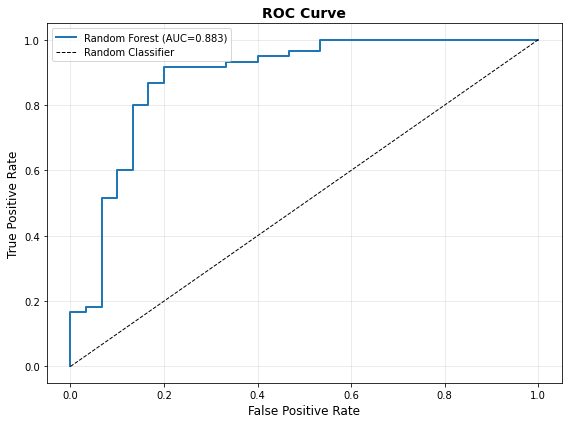


✓ AUC close to 1.0 indicates excellent discrimination


In [9]:
# 2.2 ROC Curve and AUC
print("=" * 80)
print("ROC CURVE AND AUC")
print("=" * 80)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
auc = roc_auc_score(y_test, y_test_proba)

print(f"\nAUC-ROC: {auc:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'Random Forest (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ AUC close to 1.0 indicates excellent discrimination")

PRECISION-RECALL CURVE

Average Precision: 0.9175


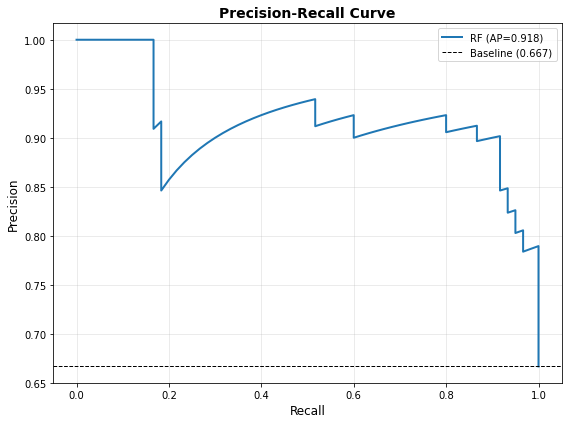


✓ For imbalanced data, PR curve is more informative than ROC


In [10]:
# 2.3 Precision-Recall Curve
# Better than ROC for imbalanced data
print("=" * 80)
print("PRECISION-RECALL CURVE")
print("=" * 80)

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_test_proba)
ap = average_precision_score(y_test, y_test_proba)

print(f"\nAverage Precision: {ap:.4f}")

# Plot PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve, linewidth=2, label=f'RF (AP={ap:.3f})')
baseline = y_test.mean()
plt.axhline(baseline, color='k', linestyle='--', linewidth=1, 
            label=f'Baseline ({baseline:.3f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ For imbalanced data, PR curve is more informative than ROC")

# Section 3: LazyPredict Framework

Demonstrates:
- Quick comparison of 40+ algorithms
- Interpreting LazyPredict outputs
- Selecting best models for tuning

In [11]:
# 3.1 LazyPredict - Rapid Model Comparison
print("=" * 80)
print("LAZYPREDICT: RAPID MODEL COMPARISON")
print("=" * 80)

try:
    from lazypredict.Supervised import LazyClassifier
    
    # Initialize LazyPredict
    clf = LazyClassifier(verbose=0, ignore_warnings=True, predictions=True)
    
    # Run on our data (trains 40+ models!)
    print("\nTraining 40+ models... (this may take a minute)\n")
    models, predictions = clf.fit(X_train_scaled, X_test_scaled, y_train, y_test)
    
    # Display top 10 models
    print("Top 10 Models by Balanced Accuracy:")
    print(models.head(10).to_string())
    
    print("\n✓ LazyPredict tested 40+ algorithms in seconds!")
    print("\nInterpretation:")
    print("  - Focus on 'Balanced Accuracy' and 'ROC AUC' for imbalanced data")
    print("  - 'Time Taken' helps identify fast vs slow algorithms")
    print("  - Pick top 3-5 models for hyperparameter tuning")
    
except (ImportError, AttributeError) as e:
    print("\n⚠️  LazyPredict compatibility issue detected.")
    print(f"Error: {type(e).__name__}")
    
    if 'StringMethods' in str(e):
        print("\nLazyPredict is incompatible with pandas 2.x")
        print("Solutions:")
        print("  1. Use maintained fork: pip uninstall lazypredict && pip install lazypredict-nightly")
        print("  2. Downgrade pandas: pip install pandas==1.5.3 (may break other packages)")
    
    print("\nDemonstrating alternative: Manual model comparison\n")
    
    # Alternative: Test a few models manually
    from sklearn.naive_bayes import GaussianNB
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.svm import SVC
    from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
    
    models_to_test = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42),
        'AdaBoost': AdaBoostClassifier(random_state=42),
        'K-Nearest Neighbors': KNeighborsClassifier(),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Naive Bayes': GaussianNB(),
        'Linear Discriminant': LinearDiscriminantAnalysis(),
        'SVM (RBF)': SVC(probability=True, random_state=42)
    }
    
    results = []
    print("Testing 10 popular ML algorithms...\n")
    
    for name, model in models_to_test.items():
        # Train
        import time
        start = time.time()
        model.fit(X_train_scaled, y_train)
        train_time = time.time() - start
        
        # Predict
        y_pred_test = model.predict(X_test_scaled)
        y_proba_test = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
        
        # Metrics
        from sklearn.metrics import balanced_accuracy_score
        acc = balanced_accuracy_score(y_test, y_pred_test)
        auc = roc_auc_score(y_test, y_proba_test) if y_proba_test is not None else 0
        
        results.append({
            'Model': name,
            'Balanced Accuracy': acc,
            'ROC AUC': auc,
            'Time (s)': train_time
        })
    
    # Create results DataFrame
    results_df = pd.DataFrame(results).sort_values('Balanced Accuracy', ascending=False)
    
    print("Model Comparison Results:")
    print(results_df.to_string(index=False))
    
    print("\n✓ Tested 10 algorithms manually")
    print("\nInterpretation:")
    print("  - Focus on 'Balanced Accuracy' and 'ROC AUC' for imbalanced data")
    print("  - 'Time' shows computational cost")
    print("  - Pick top 3-5 models for hyperparameter tuning")

LAZYPREDICT: RAPID MODEL COMPARISON

⚠️  LazyPredict compatibility issue detected.
Error: AttributeError

LazyPredict is incompatible with pandas 2.x
Solutions:
  1. Use maintained fork: pip uninstall lazypredict && pip install lazypredict-nightly
  2. Downgrade pandas: pip install pandas==1.5.3 (may break other packages)

Demonstrating alternative: Manual model comparison

Testing 10 popular ML algorithms...

Model Comparison Results:
              Model  Balanced Accuracy  ROC AUC  Time (s)
           AdaBoost           0.883333 0.937778  0.100893
      Decision Tree           0.833333 0.833333  0.007286
            XGBoost           0.833333 0.960556  0.159184
Logistic Regression           0.825000 0.891111  0.004906
  Gradient Boosting           0.808333 0.942222  0.375809
Linear Discriminant           0.791667 0.873333  0.032833
      Random Forest           0.708333 0.833889  0.113420
          SVM (RBF)           0.633333 0.811111  0.016637
K-Nearest Neighbors           0.583333

# Summary and Key Takeaways

This notebook demonstrated:

**Section 1: Fundamentals**
- Proper train/test split with stratification
- Standardization vs normalization with concrete examples
- Cross-validation for robust evaluation
- Detecting and preventing overfitting
- Regularization effects

**Section 2: Metrics**
- Confusion matrix as foundation
- All key metrics: Accuracy, Precision, Recall, Specificity, F1-Score
- ROC-AUC curves
- Precision-Recall curves for imbalanced data

**Section 3: LazyPredict**
- Rapid comparison of 40+ algorithms
- Interpreting outputs (focus on Balanced Accuracy and AUC)
- Selecting best models for tuning


**Key Lessons:**
- Biology requires careful ML due to p >> n problem (100 genes, 300 samples)
- Always use proper train/test split and cross-validation
- Report multiple metrics, not just accuracy